# 00. 先搞懂 LangGraph：用一个最简单的例子理解 State / Node / Edge

这一节只做一件事：**用一个例子——请假审批流程**，让你直觉理解 LangGraph 的 3 个核心概念：

- **State（状态）**：一张共享的“请假申请单”（所有步骤共享的一份信息）
- **Node（节点）**：一个处理步骤（一个 Python 函数）
- **Edge（边）**：步骤之间怎么走（下一步去哪）

---

## 官方怎么定义

LangGraph 官方 Graph API 文档里，明确说工作流由三部分组成：

1) **State**：共享数据快照
2) **Nodes**：接收 state，做事，然后返回更新
3) **Edges**：决定下一个执行哪个 node


## 一、从一个简单问题开始

假设你只想让程序处理一句话：

> “我要请假 2 天，理由：感冒。”

最简单的写法当然是：写一个函数，直接给一个结果：

- `2 天 <= 1 天`？不是 → 那就“需要主管审批”

问题是：真实流程会越来越复杂：

- 先登记申请（写入系统）
- 再根据天数分流（自动通过 / 主管审批）
- 主管可能拒绝，还要写回原因

当步骤一多，你会希望它像“**流程图**”一样清晰。

LangGraph 就是把你的流程，显式写成一张图。


## 二、先用同一个例子把 4 个概念钉住

> **比喻：请假申请单在公司里流转**

- **State（状态）**：这张“请假申请单”（共享信息：谁请假、几天、理由、当前状态…）
- **Node（节点）**：一个处理步骤（提交申请 / 自动审批 / 主管审批）
- **Edge（边）**：申请单下一步去哪（比如按天数分流）
- **Graph（图）**：把这些步骤和连接关系画成一张流程图

你只要记住：

> **State 是数据，Node 是步骤，Edge 是连接，Graph 是整体流程图。**


## 三、State 到底是什么？

在 LangGraph 里，你可以把 State 先当成：**一个字典**。

我们用 `TypedDict`（带类型的字典）把它写得更清楚。

请假**申请单**里我们需要记录：

- 谁请假（employee）
- 请几天（days）
- 理由（reason）
- 当前状态（status）
- 审批意见（review_comment，可选）

> 重要：节点函数只需要 **return 要修改的那几项**，其他字段保持不变。LangGraph 会把返回的 update 合并回 state。

**检查理解：**

初始 state：`{"employee": "小明", "days": 2, "reason": "感冒", "status": "新建"}`

如果一个节点 `return {"status": "已提交"}`，最终 state 是什么？

- A. `{"employee": "小明", "days": 2, "reason": "感冒", "status": "已提交"}`
- B. `{"status": "已提交"}`

答案：A（LangGraph 合并 update，不会把其他字段丢掉）。


In [1]:
from __future__ import annotations

from typing import TypedDict


class LeaveState(TypedDict, total=False):
    employee: str
    days: int
    reason: str
    status: str
    review_comment: str

## 四、Node（节点）是什么？

Node 就是一个普通 Python 函数：

- 输入：`state`
- 输出：`update`（一个 dict，表示要修改 state 的哪些字段）

我们做 3 个节点：

1) `submit`：把状态从「新建」改为「已提交」
2) `auto_approve`：天数很少（<=1）自动通过（状态变「已批准」）
3) `manager_review`：天数多（>1）走主管审批（状态变「已批准」或「已拒绝」

In [2]:
def submit(state: LeaveState) -> LeaveState:
    # return updates：只返回要改的字段
    return {"status": "已提交"}


def auto_approve(state: LeaveState) -> LeaveState:
    return {"status": "已批准", "review_comment": "自动通过（<=1 天）"}


def manager_review(state: LeaveState) -> LeaveState:
    # 这里用一个“简单规则”模拟主管审批
    if state.get("reason") and "急" in state["reason"]:
        return {"status": "已拒绝", "review_comment": "理由不充分（包含'急'）"}
    return {"status": "已批准", "review_comment": "主管审批通过"}

## 五、Edge（边）是什么？

Edge 决定“下一步去哪”。

我们的流程图是这样：

```text
START -> submit -> (按 days 分流) -> auto_approve / manager_review -> END
```

也就是：先提交，再根据请假天数走不同分支。


In [3]:
from typing import Literal

from langgraph.graph import END, START, StateGraph


def route_after_submit(state: LeaveState) -> Literal["auto_approve", "manager_review"]:
    # days <= 1：自动通过；否则走主管
    return "auto_approve" if int(state.get("days", 0)) <= 1 else "manager_review"


builder = StateGraph(LeaveState)

builder.add_node("submit", submit)
builder.add_node("auto_approve", auto_approve)
builder.add_node("manager_review", manager_review)

builder.add_edge(START, "submit")

# 条件边：从 submit 出发，根据 route_after_submit 决定下一步
# 画图时需要“可枚举的去向”，所以用 Literal + path_map 把分支说清楚
builder.add_conditional_edges(
    "submit",
    route_after_submit,
    path_map={
        "auto_approve": "auto_approve",
        "manager_review": "manager_review",
    },
)

builder.add_edge("auto_approve", END)
builder.add_edge("manager_review", END)

graph = builder.compile()

print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	submit(submit)
	auto_approve(auto_approve)
	manager_review(manager_review)
	__end__([<p>__end__</p>]):::last
	__start__ --> submit;
	submit -.-> auto_approve;
	submit -.-> manager_review;
	auto_approve --> __end__;
	manager_review --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 把图画出来

如果你看到 PNG 里 `auto_approve` / `manager_review` 没有连线，通常不是流程写错，而是**画图时的静态推断**：

- 条件边的路由函数如果只标注为 `-> str`，且没给 `path_map`，Mermaid 渲染端可能不知道“会去哪几个节点”，于是把分支简化掉。
- **这不影响运行**（`invoke()` 还是会按返回值跳转）。

上面我们已经用 `Literal[...] + path_map` 把分支去向写清楚，所以 PNG 会画出真实分支。

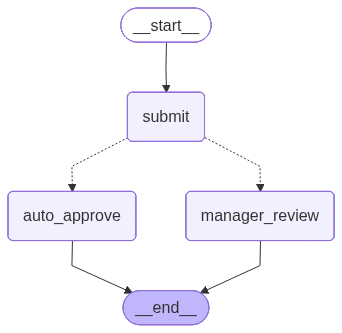

In [4]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod


display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)


## 六、运行一次：看 state 是怎么“流转”的

你只要看懂这两点就算入门了：

- 每个节点只 return 一点点 update
- 最后 `invoke()` 返回的是“流程跑完后的最终 state”


In [5]:
def run_case(employee: str, days: int, reason: str):
    init_state: LeaveState = {
        "employee": employee,
        "days": days,
        "reason": reason,
        "status": "新建",
    }
    out = graph.invoke(init_state)
    print("\n--- case ---")
    print(init_state)
    print("--- out ---")
    print(out)


run_case("小明", 1, "感冒")
run_case("小红", 3, "回家")
run_case("小张", 5, "很急")


--- case ---
{'employee': '小明', 'days': 1, 'reason': '感冒', 'status': '新建'}
--- out ---
{'employee': '小明', 'days': 1, 'reason': '感冒', 'status': '已批准', 'review_comment': '自动通过（<=1 天）'}

--- case ---
{'employee': '小红', 'days': 3, 'reason': '回家', 'status': '新建'}
--- out ---
{'employee': '小红', 'days': 3, 'reason': '回家', 'status': '已批准', 'review_comment': '主管审批通过'}

--- case ---
{'employee': '小张', 'days': 5, 'reason': '很急', 'status': '新建'}
--- out ---
{'employee': '小张', 'days': 5, 'reason': '很急', 'status': '已拒绝', 'review_comment': "理由不充分（包含'急'）"}


## 七、你现在应该记住的最核心信息

- **State**：一张共享的请假申请单（字典）
- **Node**：一个步骤（函数），输入 state，输出 update
- **Edge**：步骤之间怎么走（下一步去哪），可以是固定边，也可以是条件边
- **Graph**：把 node 和 edge 装配起来
- **compile()**：把“流程图草稿（builder）”变成“可执行的图（graph）”，并做结构检查
- **invoke()**：给图一个初始 state，让它从 `START` 跑到 `END`，返回最终 state

关于“合并规则（reducer）”先记住一句：

- 如果某个字段**没有**显式 reducer，默认就是 **覆盖（override）**（这对 `status` 很合适）。

最后一句话：

> **LangGraph 不是让你“更会写 prompt”，它是让你把多步骤流程写得像流程图一样清楚。**
